In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore") 

Image shape: (396, 396, 3)


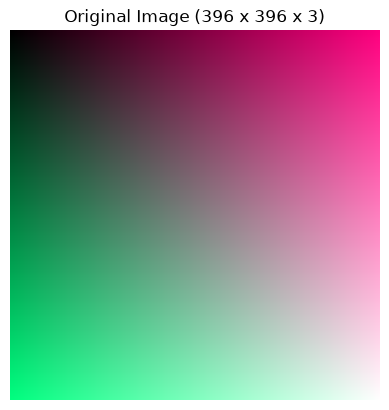

In [2]:
np.random.seed(42)
x_grid, y_grid = np.meshgrid(np.linspace(0, 255, 396), np.linspace(0, 255, 396))
r = x_grid.astype('uint8')
g = y_grid.astype('uint8')
b = ((x_grid + y_grid) / 2).astype('uint8')
image = np.stack([r, g, b], axis=-1)

print("Image shape:", image.shape)   

plt.imshow(image)
plt.title('Original Image (396 x 396 x 3)')
plt.axis('off')
plt.show()

In [3]:
x = image.reshape(-1, 3)  
print("Reshaped data shape:", x.shape) 

Reshaped data shape: (156816, 3)


In [4]:
k = 16   
model = KMeans(n_clusters=k, init='k-means++', random_state=42)
model.fit(x)

compressed_pixels = model.cluster_centers_[model.labels_]
compressed_pixels = compressed_pixels.astype('uint8')

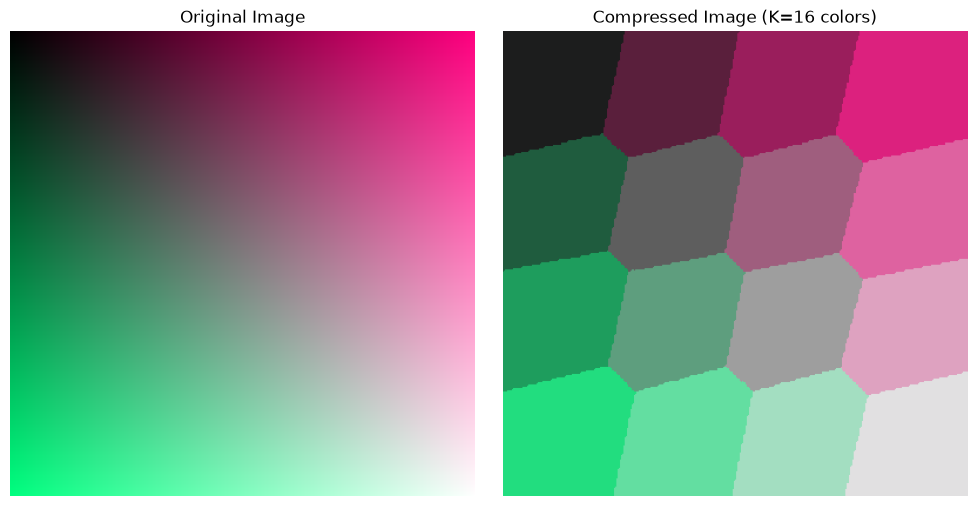

In [5]:
compressed_image = compressed_pixels.reshape(image.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title(f'Compressed Image (K={k} colors)')
axes[1].axis('off')

plt.tight_layout()
plt.show() 

In [ ]:
original_colors = len(np.unique(x, axis=0))
print("Original unique colors:", original_colors)
print("Compressed unique colors:", k)
print(f"\nColor reduction: {original_colors} -> {k}") 